In [72]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
np.random.seed(42)

n = 10000

df = pd.DataFrame({
    "Patient_ID": range(1, n+1),
    "Age": np.random.randint(20, 81, n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "Blood_Pressure": np.random.randint(80, 181, n),
    "Sugar_Level": np.random.randint(70, 201, n),
    "Cholesterol": np.random.randint(150, 301, n),
    "Heart_Rate": np.random.randint(60, 121, n)
})

print(df.head())

   Patient_ID  Age  Gender  Blood_Pressure  Sugar_Level  Cholesterol  \
0           1   58  Female             164          175          234   
1           2   71  Female             176           70          244   
2           3   48  Female             103          115          207   
3           4   34    Male             123          157          201   
4           5   62  Female             177           91          210   

   Heart_Rate  
0          77  
1          93  
2          77  
3          99  
4          90  


In [ ]:
print(df.isnull().sum())

df.fillna(df.mean(numeric_only=True), inplace=True)

Patient_ID        0
Age               0
Gender            0
Blood_Pressure    0
Sugar_Level       0
Cholesterol       0
Heart_Rate        0
dtype: int64


In [ ]:
print(df.dtypes)

Patient_ID         int64
Age                int64
Gender            object
Blood_Pressure     int64
Sugar_Level        int64
Cholesterol        int64
Heart_Rate         int64
dtype: object


In [ ]:
# Range validation
df = df[(df["Age"] >= 20) & (df["Age"] <= 80)]
df = df[(df["Blood_Pressure"] >= 80) & (df["Blood_Pressure"] <= 180)]
df = df[(df["Sugar_Level"] >= 70) & (df["Sugar_Level"] <= 200)]
df = df[(df["Cholesterol"] >= 150) & (df["Cholesterol"] <= 300)]
df = df[(df["Heart_Rate"] >= 60) & (df["Heart_Rate"] <= 120)]

# Standardize Gender values
df["Gender"] = df["Gender"].str.strip().str.capitalize()
df = df[df["Gender"].isin(["Male", "Female"])]

# Ensure correct data types
df = df.astype({
    "Age": int,
    "Blood_Pressure": int,
    "Sugar_Level": int,
    "Cholesterol": int,
    "Heart_Rate": int
})

# Remove duplicate Patient IDs
df = df.drop_duplicates(subset="Patient_ID")

In [ ]:
print(df.mean(numeric_only=True))

Patient_ID        5000.5000
Age                 50.2904
Blood_Pressure     129.6681
Sugar_Level        135.6182
Cholesterol        224.5685
Heart_Rate          89.8909
dtype: float64


In [ ]:
print(df.median(numeric_only=True))

Patient_ID        5000.5
Age                 50.0
Blood_Pressure     130.0
Sugar_Level        136.0
Cholesterol        224.0
Heart_Rate          90.0
dtype: float64


In [ ]:
print(df.mode().iloc[0])

Patient_ID            1
Age                73.0
Gender             Male
Blood_Pressure     94.0
Sugar_Level       156.0
Cholesterol       159.0
Heart_Rate         76.0
Name: 0, dtype: object


In [ ]:
print(df.std(numeric_only=True))

Patient_ID        2886.895680
Age                 17.588957
Blood_Pressure      29.138093
Sugar_Level         37.843946
Cholesterol         43.604943
Heart_Rate          17.483803
dtype: float64


In [ ]:
print(df["Blood_Pressure"].describe())

count    10000.000000
mean       129.668100
std         29.138093
min         80.000000
25%        104.000000
50%        130.000000
75%        155.000000
max        180.000000
Name: Blood_Pressure, dtype: float64


In [ ]:
print(df["Sugar_Level"].describe())

count    10000.000000
mean       135.618200
std         37.843946
min         70.000000
25%        103.000000
50%        136.000000
75%        169.000000
max        200.000000
Name: Sugar_Level, dtype: float64


In [ ]:
print(df["Cholesterol"].describe())

count    10000.000000
mean       224.568500
std         43.604943
min        150.000000
25%        187.000000
50%        224.000000
75%        262.000000
max        300.000000
Name: Cholesterol, dtype: float64


In [ ]:
print(df["Heart_Rate"].describe())

count    10000.000000
mean        89.890900
std         17.483803
min         60.000000
25%         75.000000
50%         90.000000
75%        105.000000
max        120.000000
Name: Heart_Rate, dtype: float64


In [ ]:
def classify_risk(row):
    if (row["Blood_Pressure"] > 140 or
        row["Sugar_Level"] > 180 or
        row["Cholesterol"] > 240):
        return "High"
    elif (row["Blood_Pressure"] > 120 or
          row["Sugar_Level"] > 140 or
          row["Cholesterol"] > 200):
        return "Medium"
    else:
        return "Low"

df["Risk_Level"] = df.apply(classify_risk, axis=1)

print(df["Risk_Level"].value_counts())

Risk_Level
High      6880
Medium    2402
Low        718
Name: count, dtype: int64


In [ ]:
high_risk = df[df["Risk_Level"] == "High"]

print(high_risk.head())
print("Total High Risk:", len(high_risk))

   Patient_ID  Age  Gender  Blood_Pressure  Sugar_Level  Cholesterol  \
0           1   58  Female             164          175          234   
1           2   71  Female             176           70          244   
4           5   62  Female             177           91          210   
6           7   80  Female              88          199          179   
9          10   77  Female             109          115          282   

   Heart_Rate Risk_Level  
0          77       High  
1          93       High  
4          90       High  
6          79       High  
9          69       High  
Total High Risk: 6880


In [ ]:
df["Age_Group"] = pd.cut(df["Age"],
                        bins=[20,30,40,50,60,70,80],
                        labels=["20-30","30-40","40-50","50-60","60-70","70-80"])

print(df.groupby("Age_Group")["Risk_Level"].value_counts())

Age_Group  Risk_Level
20-30      High          1104
           Medium         365
           Low             97
30-40      High          1155
           Medium         396
           Low            108
40-50      High          1137
           Medium         389
           Low            124
50-60      High          1115
           Medium         392
           Low            129
60-70      High          1108
           Medium         405
           Low            123
70-80      High          1154
           Medium         421
           Low            125
Name: count, dtype: int64


/tmp/ipykernel_1295/1386627697.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("Age_Group")["Risk_Level"].value_counts())


In [ ]:
print(df.groupby("Gender")["Risk_Level"].value_counts())

Gender  Risk_Level
Female  High          3378
        Medium        1259
        Low            338
Male    High          3502
        Medium        1143
        Low            380
Name: count, dtype: int64


In [ ]:
print(df["Risk_Level"].value_counts())

Risk_Level
High      6880
Medium    2402
Low        718
Name: count, dtype: int64


In [ ]:
print(df[["Age", "Blood_Pressure"]].corr())

                     Age  Blood_Pressure
Age             1.000000       -0.008542
Blood_Pressure -0.008542        1.000000


In [ ]:
print(df[["Cholesterol", "Heart_Rate"]].corr())

             Cholesterol  Heart_Rate
Cholesterol     1.000000    0.004685
Heart_Rate      0.004685    1.000000


In [ ]:
print(df.groupby("Risk_Level")["Sugar_Level"].mean())

Risk_Level
High      140.206977
Low       105.816156
Medium    131.383014
Name: Sugar_Level, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

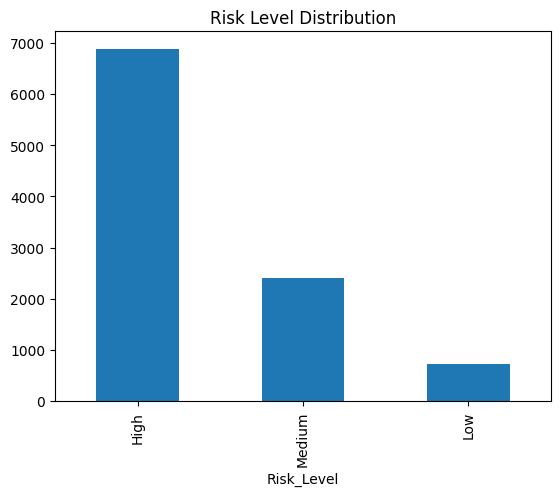

In [ ]:
df["Risk_Level"].value_counts().plot(kind="bar")
plt.title("Risk Level Distribution")
plt.show()

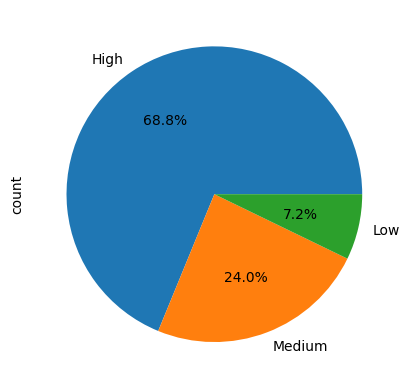

In [ ]:
df["Risk_Level"].value_counts().plot(kind="pie", autopct='%1.1f%%')
plt.show()

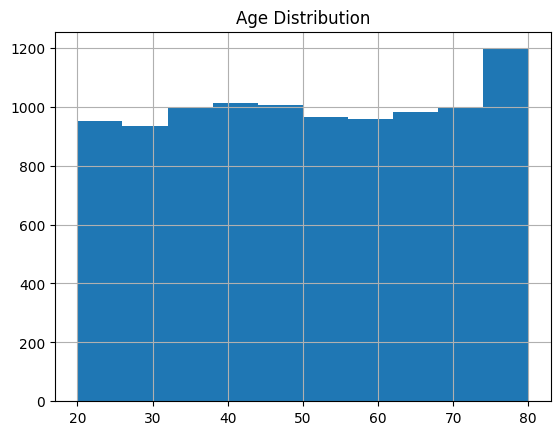

In [ ]:
df["Age"].hist()
plt.title("Age Distribution")
plt.show()

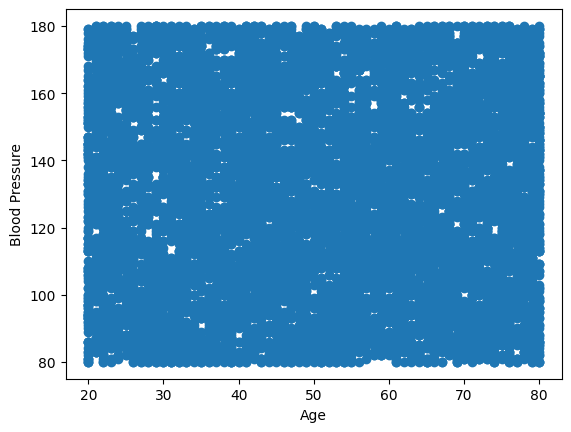

In [ ]:
plt.scatter(df["Age"], df["Blood_Pressure"])
plt.xlabel("Age")
plt.ylabel("Blood Pressure")
plt.show()

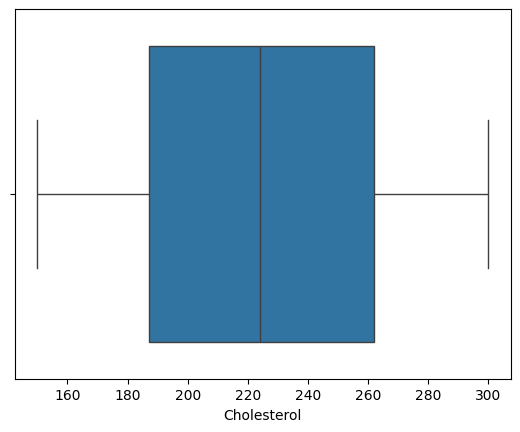

In [ ]:
sns.boxplot(x=df["Cholesterol"])
plt.show()

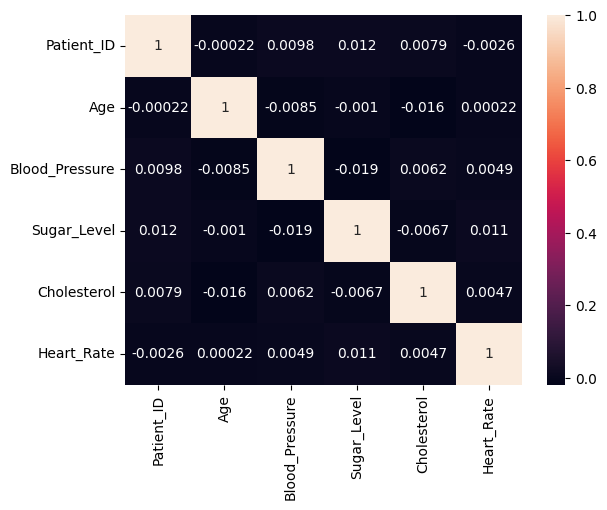

In [ ]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.show()

In [ ]:
print("High Risk Patients %:", (len(high_risk)/len(df))*100)

High Risk Patients %: 68.8


In [ ]:
print(df.groupby("Risk_Level").mean(numeric_only=True))

             Patient_ID        Age  Blood_Pressure  Sugar_Level  Cholesterol  \
Risk_Level                                                                     
High        5035.370494  50.051453      138.677616   140.206977   238.169186   
Low         5037.456825  51.201950      100.142061   105.816156   174.850975   
Medium      4889.574105  50.702331      112.688177   131.383014   200.473772   

            Heart_Rate  
Risk_Level              
High         90.038808  
Low          89.272981  
Medium       89.651957  


In [ ]:
print("Most Common Risk:", df["Risk_Level"].mode()[0])

Most Common Risk: High


In [ ]:
print("Successfully")

Successfully
